# Contexto

Este es un cuaderno de código creado para la capacitación de [ARSET](https://www.earthdata.nasa.gov/data/projects/arset) "[Estimación de PM<sub>2.5</sub> en la Superficie Usando Datos de Satélites y Otras Fuentes de Información](https://www.earthdata.nasa.gov/es/learn/trainings/estimacion-de-pm2.5-en-la-superficie-usando-datos-de-satelites-y-otras-fuentes-de)". El propósito es ilustrar cómo extraer datos de productos satelitales de PM<sub>2.5</sub> existentes para una región de interés determinada y compararlos con datos de mediciones de PM<sub>2.5</sub> obtenidas en superficie.

Autores:  
*   Carl Malings / Morgan State University & NASA Goddard Space Flight Center
*   Sebastián Diez / Centro de Investigación en Tecnologías para la Sociedad, Universidad del Desarrollo (Chile)


# Setup

Estos son los pasos de preparación necesarios para el caso de estudio:

1.   Copia este cuaderno a un lugar en tu Google Drive.
  -   Selecciona: Archivo > Guardar una copia en Drive
  -   Sugiero crear una carpeta nueva para almacenar todos los códigos y datos de este caso de estudio, para mantener tu Drive organizado. Nombré mi carpeta `PM25_Training_2026` y la coloqué dentro de mi Drive en `/content/drive/MyDrive/Colab Notebooks/ARSET/`.

2.   Crea una carpeta en tu Google Drive donde se descargarán los datos de SatPM y MERRA2_CNN. Nombré estas carpetas `SatPM_Data` y `MERRA2_CNN_Data`, y las coloqué dentro de la carpeta `PM25_Training_2026`.

3. Ejecuta el bloque de código de abajo para iniciar el entorno de Colab, cargar los paquetes requeridos e ingresar tu información de inicio de sesión. Los datos de inicio de sesión requeridos son:
* [Usuario y contraseña de NASA Earthdata](https://urs.earthdata.nasa.gov/).
* [Clave de API de OpenAQ](https://docs.openaq.org/using-the-api/api-key).


In [ ]:
# Instalar e importar los paquetes requeridos:
!pip install --quiet cartopy earthaccess

# paquetes básicos:
import os
import getpass
from google.colab import drive
import warnings
warnings.filterwarnings('ignore') # ignorar advertencias

# paquetes de análisis de datos:
import numpy as np
import pandas as pd
import xarray as xr

# paquetes de acceso a datos:
import earthaccess
import requests
import urllib
import re
import time
from urllib.parse import urljoin
from bs4 import BeautifulSoup

# paquetes de graficación:
import matplotlib.pyplot as plt
import cartopy
import seaborn as sns

# Conectar a Google Drive:
drive.mount('/content/drive')

# Almacenar la información de inicio de sesión:
# Credenciales Earthdata:
os.environ['EARTHDATA_USERNAME'] = input('Ingresa tu usuario de Earthdata: ')
os.environ['EARTHDATA_PASSWORD'] = getpass.getpass('Ingresa tu contraseña de Earthdata: ')
earthaccess.login(strategy='environment')

# Clave API OpenAQ:
s_key_openAQ = getpass.getpass('Ingresa la clave de API de OpenAQ:')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 41.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.
Mounted at /content/drive
Ingresa tu usuario de Earthdata: SebastianDiez
Ingresa tu contraseña de Earthdata: ··········
Ingresa la clave de API de OpenAQ:··········


## Definición funciones útiles


In [ ]:
# Definir funciones útiles:
def F_subset_and_combine(l_files,
                         n_lon_min,
                         n_lat_min,
                         n_lon_max,
                         n_lat_max,
                         t_start,
                         t_end,
                         s_lat= 'lat',
                         s_lon = 'lon',
                         s_time = 'time',
                         F_time_from_file = None,
                         ):
  """
  Esta función toma una lista de archivos, combina los datos de estos archivos y los recorta a la latitud, longitud y tiempo de interés.
  Entradas:
    l_files: una lista de archivos a combinar.
    n_lon_min: longitud mínima de la región de interés.
    n_lon_max: longitud máxima de la región de interés.
    n_lat_min: latitud mínima de la región de interés.
    n_lat_max: latitud máxima de la región de interés.
    t_start: tiempo de inicio de interés (como tipo numpy datetime64).
    t_end: tiempo de fin de interés (como tipo numpy datetime64).
    s_lat: nombre de la dimensión de latitud.
    s_lon: nombre de la dimensión de longitud.
    s_time: nombre de la dimensión de tiempo.
    F_time_from_file: función que toma la ruta del archivo como entrada y devuelve una marca de tiempo para asignar a los datos del archivo. Se usa para completar la dimensión de tiempo en conjuntos de datos de una sola marca temporal.
  Salidas:
    a_data: un objeto xarray con los datos de la región y período de tiempo de interés.
  """
  l_data_loaded = []
  for s_file in l_files:
    a_data_file = xr.open_dataset(s_file)
    if s_time not in a_data_file.dims:
      a_data_file = a_data_file.expand_dims({s_time:[F_time_from_file(s_file)]})
    # a_data_file_subset = a_data_file.sel(lat=slice(n_lat_min,n_lat_max),lon=slice(n_lon_min,n_lon_max),time=slice(t_start,t_end))
    a_data_file_subset = a_data_file.loc[{s_lat:slice(n_lat_min,n_lat_max),s_lon:slice(n_lon_min,n_lon_max),s_time:slice(t_start,t_end)}]
    l_data_loaded += [a_data_file_subset]
  a_data = xr.concat(l_data_loaded, dim=s_time)
  return a_data

def F_get_OpenAQ_from_API(n_lon_min,
                         n_lat_min,
                         n_lon_max,
                         n_lat_max,
                         t_start,
                         t_end,
                         l_variables=['PM2.5'],
                         b_reference = True,
                         b_lowcost = False,
                         s_key=s_key_openAQ):
  """
  Esta función consulta OpenAQ para obtener datos de monitores de calidad del aire en superficie en una región de interés y período de tiempo especificados.
  Entradas:
    n_lon_min: longitud mínima de la región de interés.
    n_lon_max: longitud máxima de la región de interés.
    n_lat_min: latitud mínima de la región de interés.
    n_lat_max: latitud máxima de la región de interés.
    t_start: tiempo de inicio de interés (como tipo numpy datetime64).
    t_end: tiempo de fin de interés (como tipo numpy datetime64).
    l_variables: lista de variables a consultar.
    b_reference: si es True, se consultarán los monitores de referencia.
    b_lowcost: si es True, se consultarán los monitores de bajo costo.
    s_key: clave de API de OpenAQ.
  Salidas:
    f_data: un dataframe de pandas con los datos de la región y período de tiempo de interés.
  """

  # Algunos diccionarios que definen los tipos de datos y las conversiones de unidades:
  d_params = {'CO':'co',
              'O3':'o3',
              'NO2':'no2',
              'SO2':'so2',
              'PM2.5':'pm25',
              'PM10':'pm10',
              'BC':'bc',
              }
  d_unit_converstions = {'CO':{'ppm':1000,
                                'ppb':1,
                                'µg/m³':0.873},
                        'O3':{'ppm':1000,
                              'ppb':1,
                              'µg/m³':0.500},
                        'NO2':{'ppm':1000,
                              'ppb':1,
                              'µg/m³':0.532},
                        'SO2':{'ppm':1000,
                              'ppb':1,
                              'µg/m³':0.382},
                        'PM2.5':{'ppm':1275.4,
                                'ppb':1.2754,
                                'µg/m³':1},
                        'PM10':{'ppm':1275.4,
                                'ppb':1.2754,
                                'µg/m³':1},
                        'BC':{'ppm':1275.4,
                              'ppb':1.2754,
                              'µg/m³':1},
                        }

  # Fechas de inicio y fin en formato datetime de pandas:
  t_start = pd.to_datetime(t_start,utc=True)
  t_end = pd.to_datetime(t_end,utc=True)
  # Consultar los IDs de los parámetros
  s_parameter_query_base = 'https://api.openaq.org/v3/parameters'
  response_parameters = requests.get(s_parameter_query_base,headers={'X-API-Key':s_key})
  if (response_parameters.status_code == 200):
    d_response_parameters = response_parameters.json()
    l_parameter_ids = []
    for d_response_parameter in d_response_parameters['results']:
      for s_variable in l_variables:
        if d_response_parameter['name'] == d_params[s_variable]:
          l_parameter_ids += [d_response_parameter['id']]
    s_parameter_ids = ','.join([str(n_parameter_id) for n_parameter_id in l_parameter_ids])
  else:
    print('ERROR: La consulta de parametros fallo')

  # Consultar los IDs de los sensores
  if (b_reference & (not b_lowcost)):
    s_location_query_base = 'https://api.openaq.org/v3/locations?limit=1000&page={n_page}&bbox={n_lon_min},{n_lat_min},{n_lon_max},{n_lat_max}&parameters_id={s_parameter_ids}&mobile=false&monitor=true'
  elif (~b_reference & b_lowcost):
    s_location_query_base = 'https://api.openaq.org/v3/locations?limit=1000&page={n_page}&bbox={n_lon_min},{n_lat_min},{n_lon_max},{n_lat_max}&parameters_id={s_parameter_ids}&mobile=false&monitor=false'
  else:
    s_location_query_base = 'https://api.openaq.org/v3/locations?limit=1000&page={n_page}&bbox={n_lon_min},{n_lat_min},{n_lon_max},{n_lat_max}&parameters_id={s_parameter_ids}&mobile=false'

  n_page = 1
  REQUERY = True
  l_sensor_ids = []
  d_sensor_latitude = {}
  d_sensor_longitude = {}
  while REQUERY:
    s_location_query = s_location_query_base.format(n_page=n_page,
                                                    n_lat_min=n_lat_min,
                                                    n_lon_min=n_lon_min,
                                                    n_lat_max=n_lat_max,
                                                    n_lon_max=n_lon_max,
                                                    s_parameter_ids=s_parameter_ids)
    response_locations = requests.get(s_location_query,headers={'X-API-Key':s_key})
    if (response_locations.status_code == 200):
      d_response_locations = response_locations.json()
      for d_location in d_response_locations['results']:
        try:
          if ((pd.to_datetime(d_location['datetimeFirst']['utc']) <= t_end) and (pd.to_datetime(d_location['datetimeLast']['utc']) >= t_start)):
            for d_sensor in d_location['sensors']:
              if d_sensor['parameter']['id'] in l_parameter_ids:
                l_sensor_ids += [d_sensor['id']]
                d_sensor_latitude[d_sensor['id']] = d_location['coordinates']['latitude']
                d_sensor_longitude[d_sensor['id']] = d_location['coordinates']['longitude']
        except:
          pass
      if d_response_locations['meta']['found'] >= (n_page*d_response_locations['meta']['limit']):
        n_page += 1
      else:
        REQUERY = False
    else:
      REQUERY = False
      print('ERROR: La consulta de ubicaciones fallo')

  # Consultar los datos:
  s_data_query_base = 'https://api.openaq.org/v3/sensors/{n_sensor_id}/measurements?limit=1000&page={n_page}&datetime_from={s_datetime_from}&datetime_to={s_datetime_to}'

  l_data = []
  for n_sensor_id in l_sensor_ids:
    n_page = 1
    REQUERY = True
    while REQUERY:
      s_data_query = s_data_query_base.format(n_sensor_id=n_sensor_id,
                                              n_page=n_page,
                                              s_datetime_from = str(t_start)[0:10]+'T'+str(t_start)[11:19]+'Z',
                                              s_datetime_to = str(t_end)[0:10]+'T'+str(t_end)[11:19]+'Z'
                                              )
      response_data = requests.get(s_data_query,headers={'X-API-Key':s_key})
      if (response_data.status_code == 200):
        d_response_data = response_data.json()
        for i_datapoint,d_datapoint in enumerate(d_response_data['results']):
          if d_datapoint['value'] is not None:
            # Encontrar el tipo de dato:
            s_type = [s_type for s_type in d_params.keys() if d_params[s_type] == d_datapoint['parameter']['name']][0]
            # Converción de las unidades:
            n_multiplier = d_unit_converstions[s_type][d_datapoint['parameter']['units']]
            n_value = d_datapoint['value']
            # Eliminar valores negativos:
            if n_value < 0:
              n_value = np.nan
            t_datapoint_start = pd.to_datetime(d_datapoint['period']['datetimeFrom']['utc'][0:19],utc=True)
            t_datapoint_end = pd.to_datetime(d_datapoint['period']['datetimeTo']['utc'][0:19],utc=True)
            d_datapoint_line = {'lat':d_sensor_latitude[n_sensor_id],
                                'lon':d_sensor_longitude[n_sensor_id],
                                'time':[(t_datapoint_start + (t_datapoint_end - t_datapoint_start)/2)],
                                s_type:[n_value*n_multiplier]}
            l_data += [pd.DataFrame.from_dict(d_datapoint_line)]
        print('Consulta completada: Sensor {}, pagina {}.'.format(n_sensor_id,n_page))
        if len(d_response_data['results']) == d_response_data['meta']['limit']:
          n_page += 1
        else:
          REQUERY = False
      else:
        REQUERY = False
        print('ERROR: La consulta de datos del sensor {} fallo'.format(n_sensor_id))

  if len(l_data) > 0:
    f_data = pd.concat(l_data, ignore_index=True)
    # Corregir indices no unicos
    f_data = f_data.groupby(['lat','lon','time']).mean()
  else:
    f_data = None

  return f_data

def F_plot_map(a_data_plot=None,
               a_data_plot_point=None,
               n_lat_min=-90,
               n_lat_max=90,
               n_lon_min=-180,
               n_lon_max=180,
               my_cmap = plt.get_cmap('Oranges'),
               Colorbar_Label = None,
               Plot_Title = None,
               Colorbar_Limits = [0,1],
               n_pointsize = 20,
               n_latlon_gridspacing = 1,
               o_figure = None,
               o_axis = None,
               o_plot = None,
               SHOW=True,
               b_shapefiles=True):
  """
  Esta función crea un mapa a partir de datos en grilla o de datos puntuales.
  Entradas:
    a_data_plot: datos en grilla (en formato xarray) para graficar en el mapa.
    a_data_plot_point: datos puntuales (en formato de tabla de pandas) para graficar en el mapa.
    n_lat_min: latitud mínima del mapa.
    n_lat_max: latitud máxima del mapa.
    n_lon_min: longitud mínima del mapa.
    n_lon_max: longitud máxima del mapa.
    my_cmap: escala de color que usará el gráfico.
    Colorbar_Label: etiqueta para la escala de color.
    Plot_Title: título del gráfico.
    Colorbar_Limits: límites para la escala de color.
    n_pointsize: tamaño de punto para los datos puntuales.
    n_latlon_gridspacing: espaciado entre las líneas de latitud y longitud en el mapa.
    o_figure: objeto de figura a usar para el gráfico.
    o_axis: objeto de eje a usar para el gráfico.
    o_plot: objeto de gráfico a usar para el gráfico.
    SHOW: si es True, se mostrará el gráfico.
    b_shapefiles: si es True, se incluirán fronteras y líneas de costa en el gráfico.
  Salidas:
    o_figure: objeto de figura usado para el gráfico.
    o_axis: objeto de eje usado para el gráfico.
    o_plot: objeto de gráfico usado para el gráfico.
  """
  if o_figure is None:
    o_figure,o_axis = plt.subplots(1,1)
    o_axis.remove()
    o_axis = o_figure.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
  if b_shapefiles:
    o_axis.coastlines()
    o_axis.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none', linestyle='-')
    o_axis.add_feature(cartopy.feature.BORDERS, edgecolor='black', facecolor='none', linestyle='--')
    o_axis.add_feature(cartopy.feature.STATES, edgecolor='black', facecolor='none', linestyle=':')
  o_axis.set_extent([np.max([n_lon_min-0.001,-180]), np.min([n_lon_max+0.001,180]), np.max([n_lat_min-0.001,-90]), np.min([n_lat_max+0.001,90])])
  gridlines = o_axis.gridlines(crs=cartopy.crs.PlateCarree(), xlocs=range(np.int_(np.floor(np.max([n_lon_min,-180]))),np.int_(np.ceil(np.min([n_lon_max,180])))+1,n_latlon_gridspacing), ylocs=range(np.int_(np.floor(np.max([n_lat_min,-90]))),np.int_(np.ceil(np.min([n_lat_max,90])))+1,n_latlon_gridspacing), draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
  gridlines.top_labels = False
  gridlines.right_labels = False
  if a_data_plot is not None:
    if 'time' in a_data_plot.dims:
      # tomar el promedio para graficar:
      a_data_plot = a_data_plot.mean(dim='time')
  else:
    # Crear un conjunto de datos sintético para habilitar la barra de color:
    if Colorbar_Limits is None:
      a_data_plot = xr.DataArray([[Colorbar_Limits[0],Colorbar_Limits[0]],[Colorbar_Limits[1],Colorbar_Limits[1]]],dims=('lat','lon'),coords={'lat':[n_lat_max+1,n_lat_max+2],'lon':[n_lon_max+1,n_lon_max+2]})
    else:
      a_data_plot = xr.DataArray([[0,1],[2,3]],dims=('lat','lon'),coords={'lat':[n_lat_max+1,n_lat_max+2],'lon':[n_lon_max+1,n_lon_max+2]})
  if Colorbar_Limits is None:
    if Colorbar_Label is not None:
      o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,cbar_kwargs={'label': Colorbar_Label})
    else:
      o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap)
  else:
    if Colorbar_Label is not None:
      o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1],cbar_kwargs={'label': Colorbar_Label})
    else:
      o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1])
  if a_data_plot_point is not None:
    if type(a_data_plot_point) is pd.Series:
        f_data_plot_point = a_data_plot_point
        if 'time' in f_data_plot_point.index.names:
            f_data_plot_point = f_data_plot_point.groupby(['lat','lon']).mean('time')
        v_lat_plot = f_data_plot_point.reset_index()['lat'].values
        v_lon_plot = f_data_plot_point.reset_index()['lon'].values
        v_data_temp = f_data_plot_point.values
    else:
        v_lat_plot = np.array(a_data_plot_point.lat)
        v_lon_plot = np.array(a_data_plot_point.lon)
        if 'time' in a_data_plot_point.dims:
          # tomar el promedio para graficar:
          v_data_temp = np.array(a_data_plot_point.mean(dim='time'))
        else:
          v_data_temp = np.array(a_data_plot_point)
    if Colorbar_Limits is None:
      o_plot_point = o_axis.scatter(x=v_lon_plot,y=v_lat_plot,s=n_pointsize,edgecolors='k',c=v_data_temp,cmap=my_cmap)
    else:
      o_plot_point = o_axis.scatter(x=v_lon_plot,y=v_lat_plot,s=n_pointsize,edgecolors='k',c=v_data_temp,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1],cmap=my_cmap)
  if Plot_Title is not None:
    o_axis.set_title(Plot_Title)
  if SHOW:
    o_figure.show()
  return o_figure,o_axis,o_plot

def F_compute_metrics(f_data,
                      s_time = 'time_month_start',
                      s_value = 'Average',
                      s_estimate = 'SatPM',
                      b_print = True):

  """
  Esta función calcula métricas de desempeño estándar para un conjunto de datos.
  Entradas:
    f_data: un dataframe de pandas con los datos. El índice debe tener tres niveles, correspondientes a latitud, longitud y tiempo.
    s_time: nombre de la dimensión de tiempo.
    s_value: nombre de la columna que contiene los valores medidos.
    s_estimate: nombre de la columna que contiene los valores estimados.
    b_print: si es True, se imprimirán las métricas.
  Salidas:
    d_metrics: un diccionario de valores de métricas calculados a partir de los datos.
  """
  d_metrics = {}

  f_data['error'] = f_data[s_estimate] - f_data[s_value]
  d_metrics['Estimated Mean'] = f_data[s_estimate].mean()
  d_metrics['Measured Mean'] = f_data[s_value].mean()
  d_metrics['Bias'] = f_data['error'].mean()
  d_metrics['Mean Normalized Bias'] = d_metrics['Bias']/d_metrics['Measured Mean']
  d_metrics['RMSE'] = np.sqrt((f_data['error']**2).mean())
  d_metrics['Mean Normalized RMSE'] = d_metrics['RMSE']/d_metrics['Measured Mean']
  d_metrics['R^2'] = 1 - (f_data['error']**2).sum()/((f_data[s_value] - d_metrics['Measured Mean'])**2).sum()

  unique_coordinates = f_data.index.droplevel(s_time).unique()
  unique_times = f_data.index.unique(level=s_time)

  # correlacion espacial
  if len(unique_coordinates) > 1:
    l_spatial_correlation_by_time = []
    for t_time in unique_times:
      f_data_temp = f_data.xs(t_time,level=s_time)
      try:
        l_spatial_correlation_by_time += [f_data_temp[s_value].corr(f_data_temp[s_estimate])]
      except:
        pass
    d_metrics['Spatial Correlation - median'] = np.nanmedian(l_spatial_correlation_by_time)
    d_metrics['Spatial Correlation - maximum'] = np.nanmax(l_spatial_correlation_by_time)
    d_metrics['Spatial Correlation - minimum'] = np.nanmin(l_spatial_correlation_by_time)

  # correlacion temporal
  if len(unique_times) > 1:
    l_temporal_correlation_by_grid = []
    for coord in unique_coordinates:
      f_data_temp = f_data.loc[coord]
      try:
        l_temporal_correlation_by_grid += [f_data_temp[s_value].corr(f_data_temp[s_estimate])]
      except:
        pass
    d_metrics['Temporal Correlation - median'] = np.nanmedian(l_temporal_correlation_by_grid)
    d_metrics['Temporal Correlation - maximum'] = np.nanmax(l_temporal_correlation_by_grid)
    d_metrics['Temporal Correlation - minimum'] = np.nanmin(l_temporal_correlation_by_grid)

  if b_print:
    for s_metric in d_metrics:
      if ' - ' in  s_metric:
        s_metric_base = s_metric.split(' - ')[0]
        s_metric_modifier = s_metric.split(' - ')[1]
        if s_metric_modifier == 'median':
          print(f'{s_metric_base}: {d_metrics[s_metric]:.3g} ({d_metrics[s_metric_base+" - minimum"]:.3g} to {d_metrics[s_metric_base+" - maximum"]:.3g})')
      else:
        print(f'{s_metric}: {d_metrics[s_metric]:.3g}')

  return d_metrics


## Funciones de scraping datos SINCA (red monitores de referencia calidad del aire en Chile)

Estas funciones extraen datos de PM<sub>2.5</sub> de monitores en superficie de la red oficial de monitoreo de Chile, **SINCA**
(Sistema de Información Nacional de Calidad del Aire).
Se usan como alternativa a OpenAQ para este caso de estudio.

**¿Por qué SINCA en lugar de OpenAQ para este caso de estudio?** OpenAQ ingiere principalmente registros *validados*. Para episodios recientes o extremos (por ejemplo, los megaincendios de febrero de 2023) las estaciones chilenas reportan datos marcados como *no validados* en SINCA, por lo que esos valores están en gran medida ausentes de OpenAQ — precisamente cuando la señal satelital es más fuerte.
OpenAQ además recopila los datos de PM<sub>2.5</sub> de los monitores de SINCA como promedios móviles de 24 horas. En este caso de estudio queremos observar los datos de promedio horario, para captar mejor los valores extremos debidos a los incendios.
SINCA expone series validadas, preliminares y no validadas de datos de promedio horario, por lo que sí captura el episodio de incendios.
El adaptador de abajo devuelve los datos en el mismo formato que `F_get_OpenAQ_from_API`, de modo que el resto del notebook no cambia.

En este caso de estudio, usaremos tanto OpenAQ como el extractor de datos de SINCA, y compararemos los resultados, para ilustrar por qué elegimos usar los datos de SINCA obtenidos mediante el extractor en lugar de los de OpenAQ.
**En general, siempre es mejor verificar la fuente original de los datos; los investigadores y expertos locales que recopilaron los datos sabrán mejor cómo usarlos apropiadamente.**


In [ ]:
# Endpoints del sitio público de SINCA:
BASE        = "https://sinca.mma.gob.cl"
REGION_URL  = f"{BASE}/index.php/region/index/id"
TS_CGI      = f"{BASE}/cgi-bin/APUB-MMA/apub.tsindico2.cgi"
HEADERS     = {"User-Agent": "Mozilla/5.0"}

def yymmdd(date_like):
    """Convierte una fecha como '2023-02-01' al formato AAMMDD de SINCA."""
    return pd.to_datetime(date_like).strftime("%y%m%d")

def as_list(x):
    return list(x) if isinstance(x, (list, tuple, set)) else [x]

def get_sinca_region_stations(region_id):
    """Lista las estaciones de una región de SINCA. Ejemplo: region_id='VIII' (Biobío)."""
    r = requests.get(f"{REGION_URL}/{region_id}", headers=HEADERS, timeout=30)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")
    stations = []
    for a in soup.find_all("a", href=True):
        href = a["href"]
        if "/index.php/estacion/index/id/" not in href:
            continue
        full_url = urljoin(BASE, href)
        m = re.search(r"/id/(\d+)", full_url)
        name = a.get_text(" ", strip=True)
        if m and name:
            stations.append({"region_id": region_id, "station_id": m.group(1),
                             "station_name": name, "station_url": full_url})
    return pd.DataFrame(stations).drop_duplicates().reset_index(drop=True)

def get_sinca_station_metadata(station_url):
    """Extrae lat/lon (del JS de Google Maps) y metadatos básicos."""
    r = requests.get(station_url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    html = r.text
    lat = lon = None
    m = re.search(r"new\s+google\.maps\.LatLng\(\s*([-+]?\d+\.\d+)\s*,\s*([-+]?\d+\.\d+)\s*\)", html)
    if m:
        lat, lon = float(m.group(1)), float(m.group(2))
    return {"lat": lat, "lon": lon}

def get_sinca_station_graph_links(station_url):
    """Encuentra los enlaces de datos/gráficos en la página de una estación."""
    r = requests.get(station_url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")
    rows = []
    for a in soup.find_all("a", href=True):
        href = urljoin(BASE, a["href"])
        if "apub.htmlindico2.cgi" in href:
            rows.append({"link_text": a.get_text(" ", strip=True), "graph_url": href})
    return pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

def get_sinca_macro_options(graph_url):
    """Extrae el valor 'macro' (requerido por el CGI de descarga) del marco izquierdo."""
    r = requests.get(graph_url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    m_tag = re.search(r'<frame[^>]*\bid=["\']left["\'][^>]*>', r.text, flags=re.IGNORECASE | re.DOTALL)
    if not m_tag:
        raise RuntimeError("No se encontro el marco izquierdo.")
    m_src = re.search(r'\bsrc="([^"]*)"', m_tag.group(0), flags=re.IGNORECASE)
    if not m_src:
        raise RuntimeError("No se encontro el src del marco izquierdo.")
    left_url = urljoin(BASE, m_src.group(1).replace("&amp;", "&"))
    r2 = requests.get(left_url, headers=HEADERS, timeout=30)
    r2.raise_for_status()
    soup = BeautifulSoup(r2.text, "html.parser")
    opts = [{"option_text": o.get_text(" ", strip=True), "macro_value": o.get("value")}
            for o in soup.select("select#ic option")]
    return pd.DataFrame(opts)

def _parse_sinca_hourly(raw_text):
    """Parsea el CSV horario de SINCA por POSICION DE COLUMNA.
    Disposición observada:  FECHA;HORA;<validado>;<preliminar>;<no_validado>;
    Las dos primeras columnas suelen estar vacías; los datos recientes/extremos
    residen en la columna 'no_validado'. Preferimos validado > preliminar > no_validado,
    y conservamos el estado para poder reportarlo de forma honesta."""
    recs = []
    for line in raw_text.splitlines():
        line = line.strip()
        if not line or line.startswith("FECHA"):
            continue
        p = line.split(";")
        if len(p) < 5:
            continue
        fecha, hora = p[0].strip(), p[1].strip()
        cols = [c.strip().replace(",", ".") for c in p[2:5]]
        def num(x):
            try: return float(x) if x != "" else None
            except ValueError: return None
        validated, preliminary, not_valid = num(cols[0]), num(cols[1]), num(cols[2])
        if validated is not None:
            val, status = validated, "validated"
        elif preliminary is not None:
            val, status = preliminary, "preliminary"
        elif not_valid is not None:
            val, status = not_valid, "not_validated"
        else:
            val, status = None, "no_data"
        recs.append({"datetime_local": pd.to_datetime("20" + fecha + hora,
                                                       format="%Y%m%d%H%M", errors="coerce"),
                     "PM2.5": val, "status": status})
    return pd.DataFrame(recs)

def _download_one_station_pm25(station_row, date_from, date_to):
    """Descarga el PM2.5 horario de una sola estación de SINCA; None si no está disponible."""
    df_links = get_sinca_station_graph_links(station_row["station_url"])
    cand = df_links[df_links["graph_url"].str.contains("PM25", case=False, na=False) &
                    df_links["graph_url"].str.contains("horario.horario", case=False, na=False)]
    if cand.empty:
        return None
    df_opt = get_sinca_macro_options(cand.iloc[0]["graph_url"])
    m = df_opt[df_opt["option_text"].str.contains("registro horario", case=False, na=False)]
    if m.empty:
        return None
    params = {"outtype": "xcl", "macro": m.iloc[0]["macro_value"],
              "from": yymmdd(date_from), "to": yymmdd(date_to),
              "path": "/usr/airviro/data/CONAMA/", "lang": "esp", "rsrc": "", "macropath": ""}
    r = requests.get(TS_CGI, params=params, headers=HEADERS, timeout=60)
    r.raise_for_status()
    raw = r.content.decode("utf-8", errors="replace")
    if "psgraph:" in raw or "Could not load macro" in raw:
        return None
    df = _parse_sinca_hourly(raw)
    meta = get_sinca_station_metadata(station_row["station_url"])
    df["lat"], df["lon"] = meta["lat"], meta["lon"]
    df["station_name"] = station_row["station_name"]
    return df

def F_get_SINCA_from_web(n_lon_min, n_lat_min, n_lon_max, n_lat_max,
                         t_start, t_end, regions, l_variables=["PM2.5"]):
    """Reemplazo directo de F_get_OpenAQ_from_API, leyendo desde SINCA.

    Devuelve un DataFrame de pandas con un índice de 3 niveles (lat, lon, time) y una
    columna 'PM2.5', con el tiempo en UTC — exactamente el formato que espera el resto
    del cuaderno. SINCA sirve regiones completas, así que pasa los ids de región que
    cubren el bounding box; los resultados luego se recortan al box.
    """
    frames = []
    for region_id in as_list(regions):
        try:
            df_st = get_sinca_region_stations(region_id)
        except Exception as e:
            print(f"Fallo el listado de la REGION {region_id}: {e}")
            continue
        for _, row in df_st.iterrows():
            try:
                d = _download_one_station_pm25(row, pd.to_datetime(t_start), pd.to_datetime(t_end))
                if d is not None and len(d):
                    frames.append(d)
                    print(f"OK: [{region_id}] {row['station_name']} ({len(d)} filas)")
                else:
                    print(f"-- sin PM2.5 horario: [{region_id}] {row['station_name']}")
            except Exception as e:
                print(f"FALLO: [{region_id}] {row['station_name']} -> {e}")
            time.sleep(0.2)
    if not frames:
        return None
    df = pd.concat(frames, ignore_index=True)
    # SINCA reporta en hora local de Chile -> convertir a UTC (para que coincida con OpenAQ / MERRA-2):
    df["time"] = (df["datetime_local"]
                  .dt.tz_localize("America/Santiago", ambiguous="NaT", nonexistent="NaT")
                  .dt.tz_convert("UTC"))
    # Recortar al bounding box (SINCA devuelve la región completa):
    df = df.dropna(subset=["lat", "lon", "time"])
    df = df[df["lat"].between(n_lat_min, n_lat_max) & df["lon"].between(n_lon_min, n_lon_max)]
    # Formato final deseado: índice (lat, lon, time) + columna 'PM2.5':
    f_data = (df[["lat", "lon", "time", "PM2.5"]]
              .dropna(subset=["PM2.5"])
              .groupby(["lat", "lon", "time"]).mean())
    return f_data


## Define tu dominio de interés

1.   Usa `n_lat_min`, `n_lat_max`, `n_lon_min` y `n_lon_max` para definir la latitud mínima, la latitud máxima, la longitud mínima y la longitud máxima de tu dominio de interés.


2.   Usa `t_start` y `t_end` para especificar la hora de inicio y de fin de tu intervalo de análisis. El formato de tiempo es `'AAAA-MM-DD hh:mm:ss'`; el tiempo está en UTC.

3.   Usa `s_timezone` para especificar la zona horaria en la que se realiza el análisis. Esto será útil para convertir entre UTC y hora local. Consulta la [lista de zonas horarias de la base de datos TZ](https://en.wikipedia.org/wiki/List_of_tz_database_time_zones) para ver las opciones posibles.


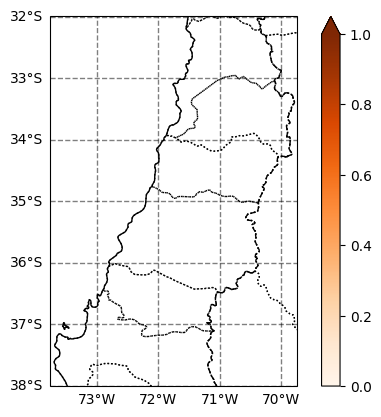

In [ ]:
# Definir el bounding box (dominio):
n_lat_min = -38
n_lat_max = -32
n_lon_min = -73.75
n_lon_max = -69.75

# Definir la fecha y hora de inicio y de fin:
t_start = np.datetime64('2022-12-01 00:00:00')
t_end = np.datetime64('2023-03-31 23:59:59')

# Especificar la zona horaria local (esto será útil para la visualización posterior):
s_timezome = 'America/Santiago'

# Veamos la región que seleccionamos para verificar que es la que queremos:
F_plot_map(n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max);


# Descarga de datos


## Descargar datos de SatPM

Este código descarga datos del dataset [SatPM V6.GL.03](https://www.satpm.org/v6-gl-03) para nuestra región y período de interés.
Alternativamente, podrías descargar manualmente los archivos desde el [sitio web de acceso a datos de SatPM](https://www.satpm.org/data-access) y volver a subirlos a tu Google Drive, pero este código ayuda a automatizar ese proceso y evita que tengas que descargar los archivos a tu computadora.


In [ ]:
# Especificar la carpeta de tu drive donde se descargarán los datos:
s_folder_SatPM = '/content/drive/MyDrive/Colab Notebooks/ARSET/PM25_Training_2026/SatPM_Data'

# Descargar los datos para el rango de tiempo de interés:
l_files_SatPM = []
for t_month in np.arange(t_start.astype('datetime64[M]'),t_end.astype('datetime64[M]')+np.timedelta64(1,'M'),np.timedelta64(1,'M')):
  s_year = str(t_month)[0:4]
  s_month = str(t_month)[5:7]
  s_url = f'https://s3.amazonaws.com/satpmdata/V6GL03/FineResolution/GL/Monthly/{s_year}/V6GL03.CNNPM25.GL.{s_year}{s_month}-{s_year}{s_month}.nc'
  s_file = s_url.split('/')[-1]
  s_download_path = os.path.join(s_folder_SatPM,s_file)
  if os.path.exists(s_download_path):
    print(f'{s_file} ya fue descargado.')
  else:
    urllib.request.urlretrieve(s_url,s_download_path)
    print(f'Se descargo {s_url} en {s_folder_SatPM}')
  l_files_SatPM += [s_download_path]

# Combinar los datos en un solo archivo:
def F_time_from_SatPM_url(s_url):
  s_YYYYMM = s_url.split('.')[-2].split('-')[0]
  return np.datetime64(f'{s_YYYYMM[0:4]}-{s_YYYYMM[4:6]}-01 00:00:00')
a_data_SatPM = F_subset_and_combine(l_files_SatPM,n_lon_min,n_lat_min,n_lon_max,n_lat_max,t_start,t_end,F_time_from_file = F_time_from_SatPM_url)

# Filtrar los valores negativos:
a_data_SatPM['PM25_filtered'] = a_data_SatPM['PM25'].where(a_data_SatPM['PM25'] > 0)

# Guardar los datos para poder retomarlos más fácilmente en el futuro:
a_data_SatPM.to_netcdf(os.path.join(s_folder_SatPM,'SatPM_data_subset.nc'))

# Observar el objeto de datos:
a_data_SatPM


V6GL03.CNNPM25.GL.202212-202212.nc ya fue descargado.
V6GL03.CNNPM25.GL.202301-202301.nc ya fue descargado.
V6GL03.CNNPM25.GL.202302-202302.nc ya fue descargado.
V6GL03.CNNPM25.GL.202303-202303.nc ya fue descargado.


<xarray.Dataset> Size: 8MB
Dimensions:        (time: 4, lat: 600, lon: 400)
Coordinates:
  * time           (time) datetime64[s] 32B 2022-12-01 2023-01-01 ... 2023-03-01
  * lat            (lat) float32 2kB -37.99 -37.99 -37.97 ... -32.01 -32.01
  * lon            (lon) float32 2kB -73.75 -73.74 -73.72 ... -69.76 -69.75
Data variables:
    PM25           (time, lat, lon) float32 4MB 22.36 22.29 22.3 ... 10.82 11.12
    PM25_filtered  (time, lat, lon) float32 4MB 22.36 22.29 22.3 ... 10.82 11.12
Attributes:
    TITLE:            Convolutional Neural Network Monthly PM2.5 Estimation o...
    CONTACT:          SIYUAN SHEN <s.siyuan@wustl.edu>
    LAT_DELTA:        0.01
    LON_DELTA:        0.01
    SPATIALCOVERAGE:  GL
    TIMECOVERAGE:     202212

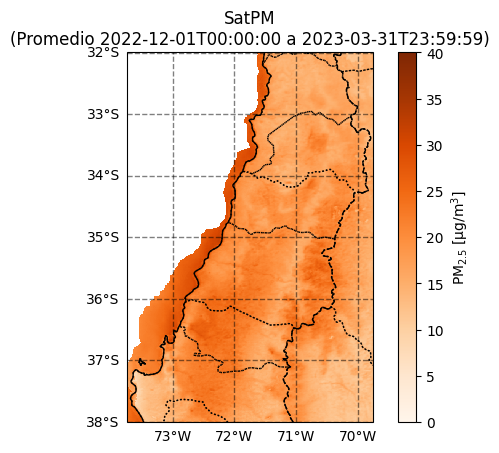

In [ ]:
# Graficar los datos:
F_plot_map(a_data_plot = a_data_SatPM['PM25_filtered'],
           n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max,
           Colorbar_Label = 'PM$_{2.5}$ [µg/m$^{3}$]',
           Plot_Title = f'SatPM\n(Promedio {t_start} a {t_end})',
           Colorbar_Limits=[0,40]);


## Descargar datos de MERRA-2 CNN

Este código descarga datos del conjunto de datos [MERRA2_CNN_HAQAST_PM25](https://doi.org/10.5067/OCKK5HCFW5N3) para nuestra región y período de tiempo de interés.
Este código usa el paquete de Python [earthaccess](https://earthaccess.readthedocs.io/en/stable/) para automatizar la búsqueda y descarga de los datos.
Alternativamente, podrías descargar manualmente los archivos usando [Earthdata Search](https://search.earthdata.nasa.gov/search?q=MERRA2_CNN_HAQAST_PM25) y volver a subirlos a tu Google Drive, pero este código ayuda a automatizar ese proceso y evita que tengas que descargar los archivos a tu computadora.


In [ ]:
# Especificar la carpeta de tu drive donde se descargarán los datos:
s_folder_MERRA2_CNN = '/content/drive/MyDrive/Colab Notebooks/ARSET/PM25_Training_2026/MERRA2_CNN_Data'

# Usar earthaccess para buscar los datos:
l_results = earthaccess.search_data(
    short_name='MERRA2_CNN_HAQAST_PM25',
    bounding_box=(n_lon_min,n_lat_min,n_lon_max,n_lat_max),
    temporal=(str(t_start),str(t_end))
)

# Usar earthaccess para descargar los datos:
l_files_MERRA2_CNN = earthaccess.download(l_results,s_folder_MERRA2_CNN)

# Combinar los datos en un solo archivo:
a_data_MERRA2_CNN = F_subset_and_combine(l_files_MERRA2_CNN,n_lon_min,n_lat_min,n_lon_max,n_lat_max,t_start,t_end)

# Filtrar los valores con banderas (flags) de baja calidad:
a_data_MERRA2_CNN['PM25_filtered'] = a_data_MERRA2_CNN['MERRA2_CNN_Surface_PM25'].where(a_data_MERRA2_CNN['QFLAG'] >= 3)

# Guardar los datos para poder retomarlos más fácilmente en el futuro:
a_data_MERRA2_CNN.to_netcdf(os.path.join(s_folder_MERRA2_CNN,'MERRA2_CNN_data_subset.nc'))

# Observar el objeto de datos:
a_data_MERRA2_CNN


QUEUEING TASKS | :   0%|          | 0/121 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/121 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/121 [00:00<?, ?it/s]

<xarray.Dataset> Size: 4MB
Dimensions:                  (time: 2904, lat: 13, lon: 7)
Coordinates:
  * time                     (time) datetime64[ns] 23kB 2022-12-01T00:30:00 ....
  * lat                      (lat) float32 52B -38.0 -37.5 -37.0 ... -32.5 -32.0
  * lon                      (lon) float32 28B -73.75 -73.12 ... -70.62 -70.0
Data variables:
    MERRA2_CNN_Surface_PM25  (time, lat, lon) float32 1MB 0.1389 1.354 ... 1.213
    QFLAG                    (time, lat, lon) float64 2MB 4.0 4.0 ... 4.0 4.0
    PM25_filtered            (time, lat, lon) float32 1MB 0.1389 1.354 ... 1.213
Attributes: (12/33)
    Comment:                           filename: MERRA2_HAQAST_CNN_L4_V1_2022...
    Filename:                          MERRA2_HAQAST_CNN_L4_V1_20221201.nc4
    Conventions:                       CF-1
    Institution:                       NASA Goddard Space Flight Center
    References:                        http://gmao.gsfc.nasa.gov ; https://do...
    Format:                            NetCDF-4/HDF-5
    ...                                ...
    RangeEndingDate:                   2022-12-01
    RangeEndingTime:                   23:59:59.000000
    DODS_EXTRA.Unlimited_Dimension:    time
    history:                           2023-04-21 04:24:38 GMT Hyrax-1.16.3 h...
    ProcessingLevel:                   4
    MapProjection:                     Geographic lat/lon. Datum: WGS-84

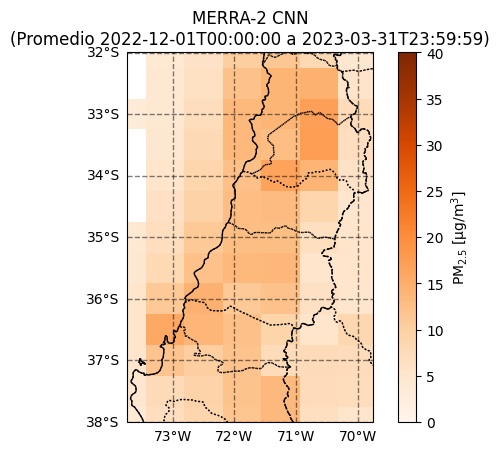

In [ ]:
# Graficar los datos:
F_plot_map(a_data_plot = a_data_MERRA2_CNN['PM25_filtered'],
           n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max,
           Colorbar_Label = 'PM$_{2.5}$ [µg/m$^{3}$]',
           Plot_Title = f'MERRA-2 CNN\n(Promedio {t_start} a {t_end})',
           Colorbar_Limits=[0,40]);


## Descargar datos de monitores desde OpenAQ y la red SINCA

Normalmente, podríamos usar un agregador de datos como la [API de OpenAQ](https://docs.openaq.org/about/about) para buscar y descargar datos de monitoreo en superficie para nuestra región y período de tiempo de interés. Para este caso de estudio, también obtendremos datos directamente de la red nacional chilena **SINCA**, usando la función escrita con ese propósito, `F_get_SINCA_from_web`. Aquí compararemos ambas fuentes, para ilustrar por qué terminamos eligiendo los datos de SINCA para este caso de estudio.


In [ ]:
# Especificar la carpeta de tu drive donde se descargarán los datos:
s_folder_Main = '/content/drive/MyDrive/Colab Notebooks/ARSET/PM25_Training_2026'

# Usar OpenAQ para consultar los datos:
f_data_monitors_OpenAQ = F_get_OpenAQ_from_API(n_lon_min,
                                               n_lat_min,
                                               n_lon_max,
                                               n_lat_max,
                                               t_start,
                                               t_end)

# Usar una función personalizada para obtener datos directamente de SINCA:
f_data_monitors_SINCA = F_get_SINCA_from_web(n_lon_min,
                                             n_lat_min,
                                             n_lon_max,
                                             n_lat_max,
                                             t_start,
                                             t_end,
                                             regions=['V', 'M', 'VI', 'VII', 'XVI', 'VIII', 'IX'])
# Ids de las regiones de SINCA que cubren el bounding box (números romanos como los usa SINCA):
# V=Valparaíso, M=Metropolitana, VI=O'Higgins, VII=Maule, XVI=Ñuble, VIII=Biobío, IX=Araucanía.

Consulta completada: Sensor 1044, pagina 1.
Consulta completada: Sensor 1044, pagina 2.
Consulta completada: Sensor 35374, pagina 1.
Consulta completada: Sensor 35374, pagina 2.
Consulta completada: Sensor 35661, pagina 1.
Consulta completada: Sensor 35661, pagina 2.
Consulta completada: Sensor 4099, pagina 1.
Consulta completada: Sensor 4099, pagina 2.
Consulta completada: Sensor 67, pagina 1.
Consulta completada: Sensor 67, pagina 2.
Consulta completada: Sensor 3013, pagina 1.
Consulta completada: Sensor 3013, pagina 2.
Consulta completada: Sensor 95, pagina 1.
Consulta completada: Sensor 95, pagina 2.
Consulta completada: Sensor 105, pagina 1.
Consulta completada: Sensor 105, pagina 2.
Consulta completada: Sensor 106, pagina 1.
Consulta completada: Sensor 106, pagina 2.
Consulta completada: Sensor 3538, pagina 1.
Consulta completada: Sensor 3538, pagina 2.
Consulta completada: Sensor 726, pagina 1.
Consulta completada: Sensor 726, pagina 2.
Consulta completada: Sensor 454, pagina 1.

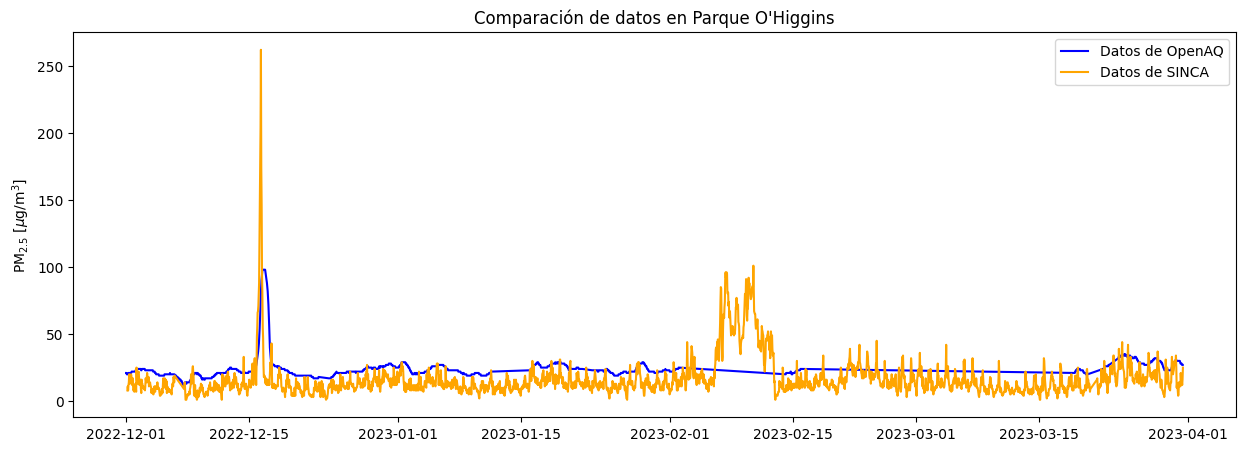

In [ ]:
# Para comparar los conjuntos de datos de OpenAQ y SINCA, graficaremos los datos en un sitio específico.

# El monitor "Parque O'Higgins" está en latitud -33.464142, longitud -70.660797
s_site = "Parque O'Higgins"
n_monitor_lat = -33.464142
n_monitor_lon = -70.660797

# Seleccionar solo los datos correspondientes a este sitio:
f_data_monitors_OpenAQ_at_site = f_data_monitors_OpenAQ.loc[(n_monitor_lat,n_monitor_lon)]
f_data_monitors_SINCA_at_site = f_data_monitors_SINCA.loc[(n_monitor_lat,n_monitor_lon)]

# Graficar la serie de tiempo:
o_fig = plt.figure(figsize=(15,5))
o_ax = o_fig.add_subplot()
o_ax.plot(f_data_monitors_OpenAQ_at_site.index,f_data_monitors_OpenAQ_at_site['PM2.5'],color='blue',label='Datos de OpenAQ')
o_ax.plot(f_data_monitors_SINCA_at_site.index,f_data_monitors_SINCA_at_site['PM2.5'],color='orange',label='Datos de SINCA')
o_ax.legend();
o_ax.set_ylabel('PM$_{2.5}$ [$\\mu$g/m$^{3}$]');
o_ax.set_title(f'Comparación de datos en {s_site}');


Al comparar las de series de tiempo de OpenAQ y SINCA, se observa que los datos de OpenAQ son mucho más suaves, y no muestran algunos de los valores pico más altos asociados a los incendios de febrero de 2023. De hecho, los datos de PM<sub>2.5</sub> de OpenAQ representan valores móviles de 24 horas, no los datos de promedio horario reportados por SINCA.

Tras consultar con expertos locales, decidimos que los datos de SINCA serían más apropiados para los objetivos de este caso de estudio.


In [ ]:
# Usar los datos de SINCA:
f_data_monitors = f_data_monitors_SINCA

# Filtrar los valores menores que 0 y mayores que 2000:
f_data_monitors['PM25_filtered'] = f_data_monitors['PM2.5'].where((f_data_monitors['PM2.5'] > 0) & (f_data_monitors['PM2.5'] < 2000))

# Guardar los datos para poder retomarlos más fácilmente en el futuro:
f_data_monitors.to_csv(os.path.join(s_folder_Main,'Monitor_data_subset.csv'))

# Ver el Data Object:
f_data_monitors


PM2.5  PM25_filtered
lat        lon        time                                           
-37.508938 -72.656093 2022-12-01 04:00:00+00:00   18.0           18.0
                      2022-12-01 05:00:00+00:00   15.0           15.0
                      2022-12-01 06:00:00+00:00   14.0           14.0
                      2022-12-01 07:00:00+00:00   15.0           15.0
                      2022-12-01 08:00:00+00:00   10.0           10.0
...                                                ...            ...
-32.718839 -71.407961 2023-03-31 22:00:00+00:00   20.0           20.0
                      2023-03-31 23:00:00+00:00   22.0           22.0
                      2023-04-01 00:00:00+00:00   25.0           25.0
                      2023-04-01 01:00:00+00:00   27.0           27.0
                      2023-04-01 02:00:00+00:00   30.0           30.0

[168736 rows x 2 columns]

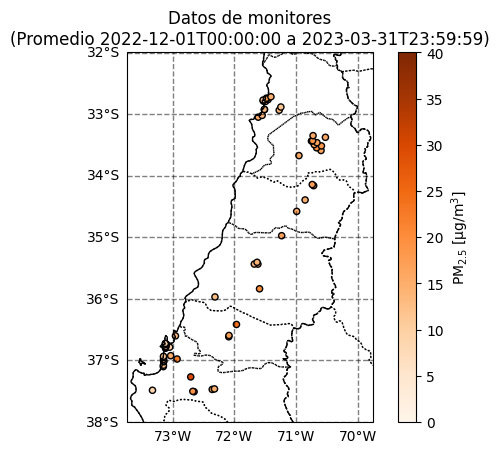

In [ ]:
# Graficar los datos:
F_plot_map(a_data_plot_point = f_data_monitors['PM25_filtered'],
           n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max,
           Colorbar_Label = 'PM$_{2.5}$ [µg/m$^{3}$]',
           Plot_Title = f'Datos de monitores\n(Promedio {t_start} a {t_end})',
           Colorbar_Limits=[0,40]);


# Análisis

Ahora realizaremos algunos análisis de los datos a los que hemos accedido.


Primero, volvamos a cargar nuestros datos desde los archivos de subconjuntos guardados en Google Drive (esto es útil si retomas el análisis más adelante, para que no necesites volver a cargar todo el conjunto de datos).


In [ ]:
# Volver a cargar los datos desde los subconjuntos guardados en tu Google Drive, si es necesario:
a_data_SatPM = xr.open_dataset(os.path.join(s_folder_SatPM,'SatPM_data_subset.nc'))
a_data_MERRA2_CNN = xr.open_dataset(os.path.join(s_folder_MERRA2_CNN,'MERRA2_CNN_data_subset.nc'))
f_data_monitors = pd.read_csv(os.path.join(s_folder_Main,'Monitor_data_subset.csv'),index_col=[0,1,2])


## Comparación usando mapas

Hagamos dos gráficos de comparación, superponiendo los datos de los monitores en superficie como puntos sobre los mapas de los conjuntos de datos de SatPM y MERRA-2 CNN.


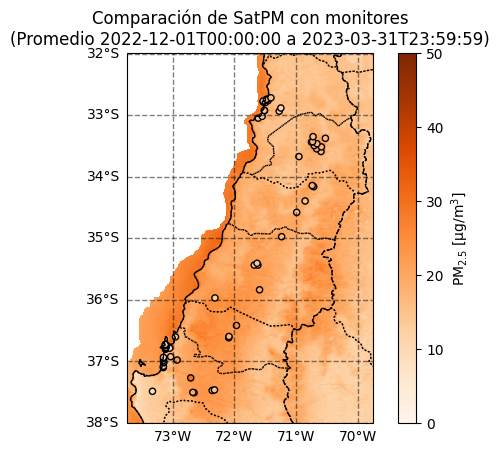

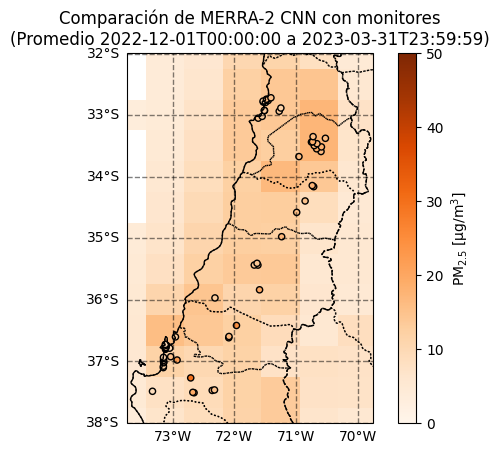

In [ ]:
# Gráfico: comparar monitores en superficie con SatPM
F_plot_map(a_data_plot = a_data_SatPM['PM25_filtered'],
           a_data_plot_point = f_data_monitors['PM25_filtered'],
           n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max,
           Colorbar_Label = 'PM$_{2.5}$ [µg/m$^{3}$]',
           Plot_Title = f'Comparación de SatPM con monitores\n(Promedio {t_start} a {t_end})',
           Colorbar_Limits=[0,50]);

# Gráfico: comparar monitores en superficie con MERRA-2 CNN
F_plot_map(a_data_plot = a_data_MERRA2_CNN['PM25_filtered'],
           a_data_plot_point = f_data_monitors['PM25_filtered'],
           n_lat_min=n_lat_min,
           n_lat_max=n_lat_max,
           n_lon_min=n_lon_min,
           n_lon_max=n_lon_max,
           Colorbar_Label = 'PM$_{2.5}$ [µg/m$^{3}$]',
           Plot_Title = f'Comparación de MERRA-2 CNN con monitores\n(Promedio {t_start} a {t_end})',
           Colorbar_Limits=[0,50]);


## Comparación de promedios mensuales entre SatPM y monitores

Para comparar los datos de los monitores con la estimación de SatPM, primero debemos promediar los datos de los monitores a una escala temporal mensual, de modo que podamos comparar los valores directamente con los promedios mensuales del conjunto de datos de SatPM.

Uso `n_minimum_samples_per_month` para especificar un número mínimo de muestras horarias necesarias para calcular un promedio mensual; esto asegura que mi promedio sea representativo de todo el mes, y no solo de unos pocos días u horas.

Este código también guarda los datos promediados mensualmente resultantes en un archivo CSV, por si quiero revisarlos más adelante.


In [ ]:
# Especificar el número mínimo de muestras válidas para calcular un promedio mensual:
n_minimum_samples_per_month = 24*20

# Crear un nuevo dataframe para ayudar a calcular los promedios mensuales:
f_data_monitors_monthly = f_data_monitors.copy().reset_index()
# Agregar una columna de tiempo con el inicio del mes:
f_data_monitors_monthly['time_month_start'] = [np.datetime64(t_time).astype('datetime64[M]') for t_time in f_data_monitors_monthly['time']]

# Calcular los promedios mensuales y las desviaciones estándar:
f_data_combined_monthly = f_data_monitors_monthly.groupby(['lat','lon','time_month_start'])[['PM25_filtered']].count().rename(columns={'PM25_filtered':'Count'})
f_data_combined_monthly['Average'] = f_data_monitors_monthly.groupby(['lat','lon','time_month_start'])[['PM25_filtered']].mean()
f_data_combined_monthly['StDev'] = f_data_monitors_monthly.groupby(['lat','lon','time_month_start'])[['PM25_filtered']].std()
# Conservar solo los promedios mensuales que cumplen el número mínimo de mediciones requeridas:
f_data_combined_monthly = f_data_combined_monthly.where(f_data_combined_monthly['Count'] >= n_minimum_samples_per_month)

# Agregar los datos mensuales de SatPM a este dataframe:
f_data_combined_monthly['SatPM'] = np.nan
for i_row in range(len(f_data_combined_monthly)):
  t_month = f_data_combined_monthly.index[i_row][2]
  n_lat = f_data_combined_monthly.index[i_row][0]
  n_lon = f_data_combined_monthly.index[i_row][1]
  f_data_combined_monthly.loc[(n_lat,n_lon,t_month),'SatPM'] = a_data_SatPM.sel(lat=n_lat,lon=n_lon,time=t_month,method='nearest')['PM25_filtered'].values

# Agregar los datos mensuales de MERRA-2 CNN a este dataframe:
f_data_combined_monthly['MERRA2_CNN'] = np.nan
for i_row in range(len(f_data_combined_monthly)):
  t_month = f_data_combined_monthly.index[i_row][2]
  n_lat = f_data_combined_monthly.index[i_row][0]
  n_lon = f_data_combined_monthly.index[i_row][1]
  f_data_combined_monthly.loc[(n_lat,n_lon,t_month),'MERRA2_CNN'] = a_data_MERRA2_CNN.sel(lat=n_lat,lon=n_lon,method='nearest')['PM25_filtered'].sel(time=slice(t_month,t_month+pd.DateOffset(months=1))).mean('time').values

# Guardar los resultados en un archivo CSV para referencia posterior:
f_data_combined_monthly.to_csv(os.path.join(s_folder_Main,'Combined_data_monthly.csv'))

# Observar el dataframe resultante:
f_data_combined_monthly


Count    Average       StDev  \
lat        lon        time_month_start                                 
-37.508938 -72.656093 2022-12-01        717.0  13.951185   23.169382   
                      2023-01-01        723.0  16.074689    9.280334   
                      2023-02-01        656.0  53.730183  116.638551   
                      2023-03-01        722.0  13.229917   10.697442   
                      2023-04-01          NaN        NaN         NaN   
...                                       ...        ...         ...   
-32.718839 -71.407961 2022-12-01        732.0  13.506831    5.577089   
                      2023-01-01        741.0  12.819163    5.072684   
                      2023-02-01        672.0  20.985119   10.257915   
                      2023-03-01        734.0  13.393733    6.876935   
                      2023-04-01          NaN        NaN         NaN   

                                            SatPM  MERRA2_CNN  
lat        lon        time_month_start                         
-37.508938 -72.656093 2022-12-01        13.756617    6.417771  
                      2023-01-01        14.076958    7.295739  
                      2023-02-01        54.076897   17.666616  
                      2023-03-01        15.826820    6.428078  
                      2023-04-01        15.826820         NaN  
...                                           ...         ...  
-32.718839 -71.407961 2022-12-01        12.825067   11.887493  
                      2023-01-01        14.022977   13.682004  
                      2023-02-01        28.822756   20.174040  
                      2023-03-01        13.428461   10.817664  
                      2023-04-01        13.428461         NaN  

[298 rows x 5 columns]

Ahora visualizo la comparación con un gráfico de dispersión y calculo algunas métricas de desempeño estándar.


Métricas de desempeño para SatPM
Estimated Mean: 20.2
Measured Mean: 15.5
Bias: 5.73
Mean Normalized Bias: 0.37
RMSE: 7.88
Mean Normalized RMSE: 0.509
R^2: 0.548
Spatial Correlation: 0.563 (0.159 to 0.778)
Temporal Correlation: 0.99 (0.758 to 1)


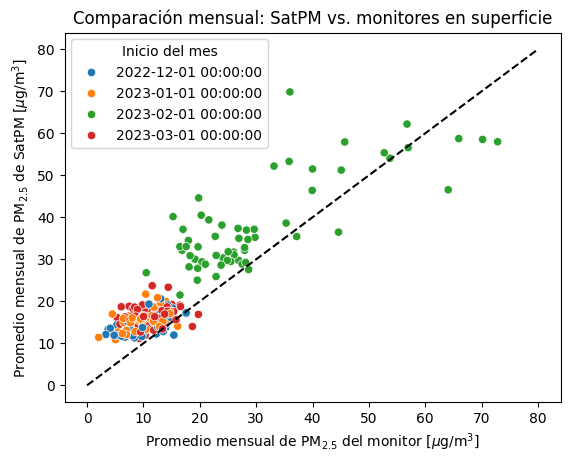

In [ ]:
# Crear un gráfico de dispersión de comparación:
o_ax = sns.scatterplot(data=f_data_combined_monthly.dropna(),x='Average',y='SatPM',hue='time_month_start');
o_ax.plot([0,80],[0,80],'k--');
o_ax.legend(title='Inicio del mes')
o_ax.set_xlabel('Promedio mensual de PM$_{2.5}$ del monitor [$\\mu$g/m$^{3}$]');
o_ax.set_ylabel('Promedio mensual de PM$_{2.5}$ de SatPM [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación mensual: SatPM vs. monitores en superficie');

# Calcular y mostrar las métricas de desempeño:
print('Métricas de desempeño para SatPM')
F_compute_metrics(f_data_combined_monthly,
                  s_time = 'time_month_start',
                  s_value = 'Average',
                  s_estimate = 'SatPM');


Métricas de desempeño para MERRA-2 CNN (mensual)
Estimated Mean: 13.6
Measured Mean: 15.5
Bias: -1.85
Mean Normalized Bias: -0.119
RMSE: 8.43
Mean Normalized RMSE: 0.544
R^2: 0.483
Spatial Correlation: 0.611 (0.0462 to 0.733)
Temporal Correlation: 0.989 (0.776 to 1)


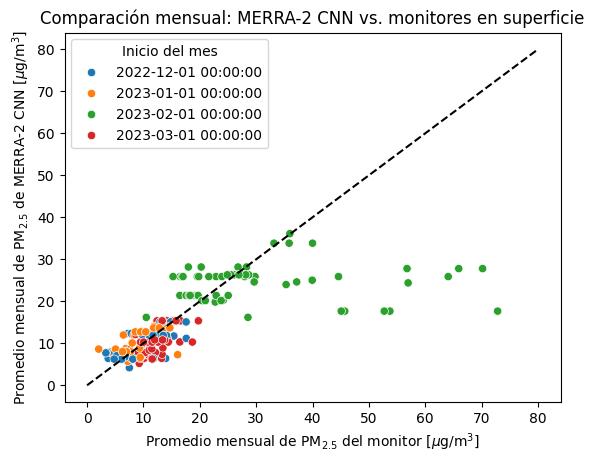

In [ ]:
# Crear un gráfico de dispersión de comparación:
o_ax = sns.scatterplot(data=f_data_combined_monthly.dropna(),x='Average',y='MERRA2_CNN',hue='time_month_start');
o_ax.plot([0,80],[0,80],'k--');
o_ax.legend(title='Inicio del mes')
o_ax.set_xlabel('Promedio mensual de PM$_{2.5}$ del monitor [$\\mu$g/m$^{3}$]');
o_ax.set_ylabel('Promedio mensual de PM$_{2.5}$ de MERRA-2 CNN [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación mensual: MERRA-2 CNN vs. monitores en superficie');

# Calcular y mostrar las métricas de desempeño:
print('Métricas de desempeño para MERRA-2 CNN (mensual)')
F_compute_metrics(f_data_combined_monthly,
                  s_time = 'time_month_start',
                  s_value = 'Average',
                  s_estimate = 'MERRA2_CNN');


## Comparación de promedios horarios de MERRA-2 CNN y monitores

Para comparar los datos de los monitores con la estimación de MERRA-2 CNN, puedo hacer una comparación directa hora a hora, ya que ambos proporcionan datos horarios. Sin embargo, la resolución espacial es mucho más gruesa, donde una celda de la grilla de MERRA-2 usualmente cubre múltiples sitios. Por eso, primero quiero agregar los datos de los monitores a las celdas de la grilla de MERRA-2, para permitir una comparación directa.

Uso `n_minimum_samples_per_grid` para especificar un número mínimo de muestras de monitores necesarias para calcular un promedio en una celda de la grilla de MERRA-2; esto asegura que mi promedio sea representativo de varios monitores en la celda, y no solo de una ubicación específica.

Este código también guarda los datos en grilla resultantes en un archivo CSV, por si quiero revisarlos más adelante.


In [ ]:
# Especificar el número mínimo de muestras válidas para calcular un promedio de celda:
n_minimum_samples_per_grid = 3

# Crear un nuevo dataframe para ayudar a calcular los promedios por celda:
f_data_monitors_gridded = f_data_monitors.copy().reset_index()

# Asignar los datos de los monitores a la celda más cercana de MERRA-2 (nota: la resolución de la grilla de MERRA-2 es 0.5 en latitud por 0.625 en longitud):
f_data_monitors_gridded['lat_grid'] = round(f_data_monitors_gridded['lat']/0.5)*0.5
f_data_monitors_gridded['lon_grid'] = round(f_data_monitors_gridded['lon']/0.625)*0.625

# Agrupar los datos por las celdas de latitud y longitud y agregar:
f_data_combined_gridded = f_data_monitors_gridded.groupby(['lat_grid','lon_grid','time'])[['PM25_filtered']].count().rename(columns={'PM25_filtered':'Count'})
f_data_combined_gridded['Average'] = f_data_monitors_gridded.groupby(['lat_grid','lon_grid','time'])[['PM25_filtered']].mean()
f_data_combined_gridded['StDev'] = f_data_monitors_gridded.groupby(['lat_grid','lon_grid','time'])[['PM25_filtered']].std()

# Filtrar los datos con menos del número requerido de muestras por celda:
f_data_combined_gridded = f_data_combined_gridded.where(f_data_combined_gridded['Count'] >= n_minimum_samples_per_grid).dropna()

# Agregar los datos horarios de MERRA-2 CNN a este dataframe (nota: también agrego columnas de hora del día y fecha local, para facilitar los pasos posteriores):
f_data_combined_gridded['MERRA2_CNN'] = np.nan
f_data_combined_gridded['local_day'] = np.nan
f_data_combined_gridded['local_hour_of_day'] = np.nan
for i_row in range(len(f_data_combined_gridded)):
  t_time = f_data_combined_gridded.index[i_row][2]
  n_lat = f_data_combined_gridded.index[i_row][0]
  n_lon = f_data_combined_gridded.index[i_row][1]
  f_data_combined_gridded.loc[(n_lat,n_lon,t_time),'MERRA2_CNN'] = a_data_MERRA2_CNN.sel(lat=n_lat,lon=n_lon,time=np.datetime64(t_time.split('+')[0]),method='nearest')['PM25_filtered'].values
  f_data_combined_gridded.loc[(n_lat,n_lon,t_time),'local_day'] = pd.to_datetime(t_time).tz_convert(s_timezome).date()
  f_data_combined_gridded.loc[(n_lat,n_lon,t_time),'local_hour_of_day'] = pd.to_datetime(t_time).tz_convert(s_timezome).hour

# Guardar los resultados en un archivo CSV para referencia posterior:
f_data_combined_gridded.to_csv(os.path.join(s_folder_Main,'Combined_data_gridded.csv'))

# Observar el dataframe resultante:
f_data_combined_gridded


Count    Average     StDev  \
lat_grid lon_grid time                                                    
-37.5    -72.50   2022-12-01 04:00:00+00:00    4.0   9.250000  5.909033   
                  2022-12-01 05:00:00+00:00    4.0   7.500000  5.259911   
                  2022-12-01 06:00:00+00:00    4.0   6.500000  5.802298   
                  2022-12-01 07:00:00+00:00    4.0   6.750000  6.238322   
                  2022-12-01 08:00:00+00:00    4.0   6.500000  3.109126   
...                                            ...        ...       ...   
-32.5    -71.25   2023-03-31 22:00:00+00:00    3.0  20.000000  2.000000   
                  2023-03-31 23:00:00+00:00    3.0  21.666667  2.516611   
                  2023-04-01 00:00:00+00:00    3.0  26.333333  4.163332   
                  2023-04-01 01:00:00+00:00    3.0  27.000000  6.000000   
                  2023-04-01 02:00:00+00:00    3.0  26.666667  4.932883   

                                             MERRA2_CNN   local_day  \
lat_grid lon_grid time                                                
-37.5    -72.50   2022-12-01 04:00:00+00:00    8.620450  2022-12-01   
                  2022-12-01 05:00:00+00:00    8.789962  2022-12-01   
                  2022-12-01 06:00:00+00:00    8.648620  2022-12-01   
                  2022-12-01 07:00:00+00:00    7.226994  2022-12-01   
                  2022-12-01 08:00:00+00:00    6.658096  2022-12-01   
...                                                 ...         ...   
-32.5    -71.25   2023-03-31 22:00:00+00:00    8.778658  2023-03-31   
                  2023-03-31 23:00:00+00:00   10.146086  2023-03-31   
                  2023-04-01 00:00:00+00:00   10.146086  2023-03-31   
                  2023-04-01 01:00:00+00:00   10.146086  2023-03-31   
                  2023-04-01 02:00:00+00:00   10.146086  2023-03-31   

                                             local_hour_of_day  
lat_grid lon_grid time                                          
-37.5    -72.50   2022-12-01 04:00:00+00:00                1.0  
                  2022-12-01 05:00:00+00:00                2.0  
                  2022-12-01 06:00:00+00:00                3.0  
                  2022-12-01 07:00:00+00:00                4.0  
                  2022-12-01 08:00:00+00:00                5.0  
...                                                        ...  
-32.5    -71.25   2023-03-31 22:00:00+00:00               19.0  
                  2023-03-31 23:00:00+00:00               20.0  
                  2023-04-01 00:00:00+00:00               21.0  
                  2023-04-01 01:00:00+00:00               22.0  
                  2023-04-01 02:00:00+00:00               23.0  

[22707 rows x 6 columns]

Ahora visualizo la comparación con un gráfico de dispersión y calculo algunas métricas de desempeño estándar.


Métricas de desempeño para MERRA-2 CNN (horario)
Estimated Mean: 13.6
Measured Mean: 15.7
Bias: -2.06
Mean Normalized Bias: -0.131
RMSE: 26.7
Mean Normalized RMSE: 1.7
R^2: 0.206
Spatial Correlation: 0.43 (-0.882 to 0.99)
Temporal Correlation: 0.51 (0.357 to 0.661)


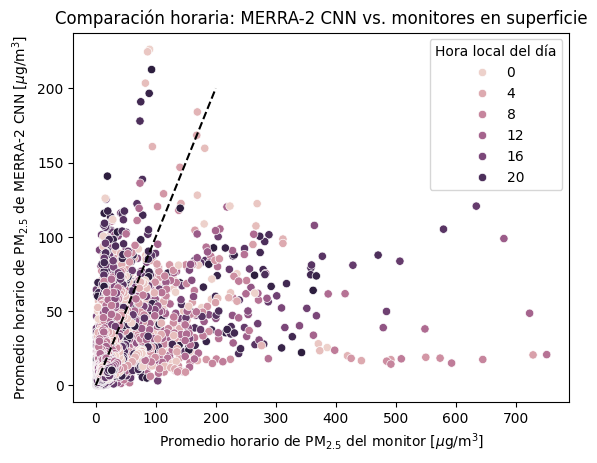

In [ ]:
# Crear un gráfico de dispersión de comparación:
o_ax = sns.scatterplot(data=f_data_combined_gridded.dropna(),x='Average',y='MERRA2_CNN',hue='local_hour_of_day')
o_ax.plot([0,200],[0,200],'k--');
o_ax.legend(title='Hora local del día');
o_ax.set_xlabel('Promedio horario de PM$_{2.5}$ del monitor [$\\mu$g/m$^{3}$]');
o_ax.set_ylabel('Promedio horario de PM$_{2.5}$ de MERRA-2 CNN [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación horaria: MERRA-2 CNN vs. monitores en superficie');

# Calcular y mostrar las métricas de desempeño:
print('Métricas de desempeño para MERRA-2 CNN (horario)')
F_compute_metrics(f_data_combined_gridded,
                  s_time = 'time',
                  s_value = 'Average',
                  s_estimate = 'MERRA2_CNN');


Otra forma de evaluar estos resultados es comparar los patrones diurnos (es decir, el ciclo de 24 horas de las concentraciones) entre MERRA-2 CNN y los monitores.


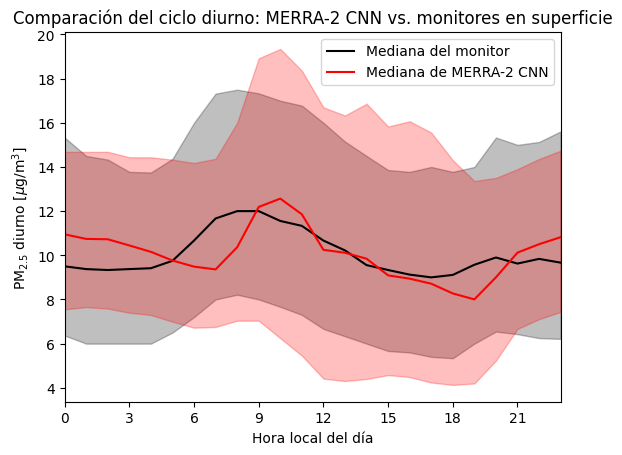

In [ ]:
# Agrupar los datos de los monitores por hora local del día y calcular la mediana:
f_data_combined_gridded_by_timeofday = f_data_combined_gridded.groupby('local_hour_of_day')[['Average']].median()
# Agregar el conteo de muestras válidas:
f_data_combined_gridded_by_timeofday['Count'] = f_data_combined_gridded.groupby('local_hour_of_day')[['Average']].count()
# Agregar los percentiles 25 y 75 de los promedios horarios por hora del día, para dar una idea de la variabilidad:
f_data_combined_gridded_by_timeofday['75th_percentile'] = f_data_combined_gridded.groupby('local_hour_of_day')[['Average']].quantile(0.75)
f_data_combined_gridded_by_timeofday['25th_percentile'] = f_data_combined_gridded.groupby('local_hour_of_day')[['Average']].quantile(0.25)
# Repetir para el conjunto de datos de MERRA-2 CNN:
f_data_combined_gridded_by_timeofday['MERRA2_CNN'] = f_data_combined_gridded.groupby('local_hour_of_day')[['MERRA2_CNN']].median()
f_data_combined_gridded_by_timeofday['MERRA2_CNN_75th_percentile'] = f_data_combined_gridded.groupby('local_hour_of_day')[['MERRA2_CNN']].quantile(0.75)
f_data_combined_gridded_by_timeofday['MERRA2_CNN_25th_percentile'] = f_data_combined_gridded.groupby('local_hour_of_day')[['MERRA2_CNN']].quantile(0.25)

# Graficar los resultados:
o_fig = plt.figure()
o_ax = o_fig.add_subplot()
o_ax.fill_between(np.arange(0,24),f_data_combined_gridded_by_timeofday['25th_percentile'],f_data_combined_gridded_by_timeofday['75th_percentile'],color='black',alpha=0.25)
o_ax.fill_between(np.arange(0,24),f_data_combined_gridded_by_timeofday['MERRA2_CNN_25th_percentile'],f_data_combined_gridded_by_timeofday['MERRA2_CNN_75th_percentile'],color='red',alpha=0.25)
o_ax.plot(np.arange(0,24),f_data_combined_gridded_by_timeofday['Average'],color='black',label='Mediana del monitor')
o_ax.plot(np.arange(0,24),f_data_combined_gridded_by_timeofday['MERRA2_CNN'],color='red',label='Mediana de MERRA-2 CNN')
o_ax.legend();
o_ax.set_xlabel('Hora local del día');
o_ax.set_xticks([0,3,6,9,12,15,18,21])
o_ax.set_xlim([0,23])
o_ax.set_ylabel('PM$_{2.5}$ diurno [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación del ciclo diurno: MERRA-2 CNN vs. monitores en superficie');


## Comparación de promedios diarios de MERRA-2 CNN y monitores

Veamos si agregar los datos a promedios diarios en lugar de horarios cambia la comparación y las estadísticas.


Métricas de desempeño para MERRA-2 CNN (diario)
Estimated Mean: 13.6
Measured Mean: 15.6
Bias: -1.98
Mean Normalized Bias: -0.127
RMSE: 20.2
Mean Normalized RMSE: 1.3
R^2: 0.362
Spatial Correlation: 0.58 (-0.486 to 0.971)
Temporal Correlation: 0.717 (0.596 to 0.921)


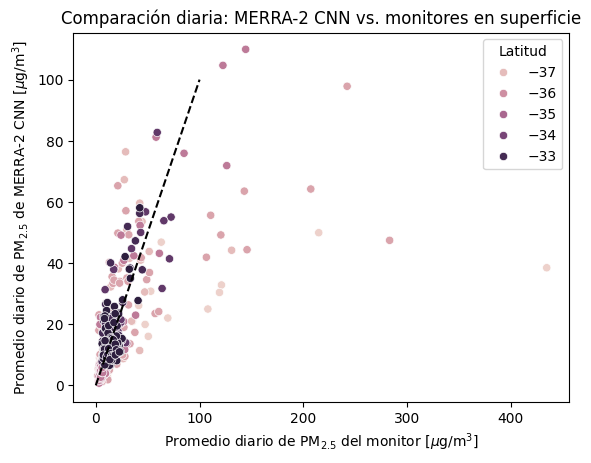

In [ ]:
# Agregar los datos según el día local:
f_data_combined_gridded_daily = f_data_combined_gridded.groupby(['lat_grid','lon_grid','local_day'])[['Average','MERRA2_CNN']].mean()

# Crear un gráfico de dispersión de comparación:
o_ax = sns.scatterplot(data=f_data_combined_gridded_daily.dropna(),x='Average',y='MERRA2_CNN',hue='lat_grid');
o_ax.plot([0,100],[0,100],'k--');
o_ax.legend(title='Latitud');
o_ax.set_xlabel('Promedio diario de PM$_{2.5}$ del monitor [$\\mu$g/m$^{3}$]');
o_ax.set_ylabel('Promedio diario de PM$_{2.5}$ de MERRA-2 CNN [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación diaria: MERRA-2 CNN vs. monitores en superficie');

# Calcular y mostrar las métricas de desempeño:
print('Métricas de desempeño para MERRA-2 CNN (diario)')
F_compute_metrics(f_data_combined_gridded_daily,
                  s_time = 'local_day',
                  s_value = 'Average',
                  s_estimate = 'MERRA2_CNN');


## Ejemplo de un análisis usando umbrales de promedio diario

Podría ser de interés observar los datos donde las concentraciones están por encima o por debajo de un cierto umbral, para comparar el desempeño durante días "limpios" frente a días "contaminados". Aquí uso `n_threshold` para especificar un valor umbral de PM<sub>2.5</sub> para el promedio diario. Según si el promedio diario está por encima o por debajo del umbral, divido el conjunto de datos horarios en dos partes. Luego calculo las estadísticas solo para los valores donde el promedio diario está por debajo del umbral, por ejemplo, para examinar el desempeño en días "relativamente limpios".


Métricas de desempeño para MERRA-2 CNN (valores por debajo del umbral):
Estimated Mean: 12.8
Measured Mean: 12.9
Bias: -0.0795
Mean Normalized Bias: -0.00616
RMSE: 13.2
Mean Normalized RMSE: 1.02
R^2: 0.0387
Spatial Correlation: 0.435 (-0.882 to 0.999)
Temporal Correlation: 0.488 (0.357 to 0.565)


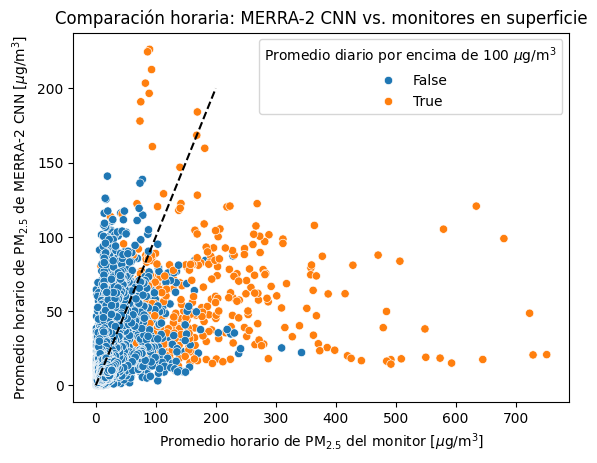

In [ ]:
# Definir el umbral deseado para el análisis:
n_threshold = 100

# Identificar los valores horarios para los cuales el promedio diario está por encima o por debajo del umbral:
f_data_combined_gridded['Daily_Average_Above_Threshold'] = False
for i_row in range(len(f_data_combined_gridded)):
  n_lat = f_data_combined_gridded.index[i_row][0]
  n_lon = f_data_combined_gridded.index[i_row][1]
  t_time = f_data_combined_gridded.index[i_row][2]
  t_day = f_data_combined_gridded.loc[(n_lat,n_lon,t_time),'local_day']
  n_daily_average = f_data_combined_gridded_daily.loc[(n_lat,n_lon,t_day),'Average']
  if n_daily_average > n_threshold:
    f_data_combined_gridded.loc[(n_lat,n_lon,t_time),'Daily_Average_Above_Threshold'] = True

# Graficar los resultados:
o_ax = sns.scatterplot(data=f_data_combined_gridded.dropna(),x='Average',y='MERRA2_CNN',hue='Daily_Average_Above_Threshold')
o_ax.plot([0,200],[0,200],'k--');
o_ax.legend(title='Promedio diario por encima de '+str(n_threshold)+' $\\mu$g/m$^{3}$');
o_ax.set_xlabel('Promedio horario de PM$_{2.5}$ del monitor [$\\mu$g/m$^{3}$]');
o_ax.set_ylabel('Promedio horario de PM$_{2.5}$ de MERRA-2 CNN [$\\mu$g/m$^{3}$]');
o_ax.set_title('Comparación horaria: MERRA-2 CNN vs. monitores en superficie');

# Calcular y mostrar las métricas de desempeño, considerando solo los datos por debajo del umbral:
print('Métricas de desempeño para MERRA-2 CNN (valores por debajo del umbral):')
F_compute_metrics(f_data_combined_gridded[f_data_combined_gridded['Daily_Average_Above_Threshold'] == False],
                  s_time = 'time',
                  s_value = 'Average',
                  s_estimate = 'MERRA2_CNN');


## Serie de tiempo para una ubicación

Finalmente, visualicemos estos datos diarios como una serie de tiempo para una ubicación. Esto se puede hacer restringiendo nuestro conjunto de datos solo a las coordenadas de una ubicación de interés. En el código de abajo, he especificado algunas ubicaciones de interés en nuestra región de estudio mediante sus coordenadas correspondientes en el conjunto de datos de MERRA-2 CNN. Se podría definir una lista personalizada de coordenadas de interés para tu región de estudio.


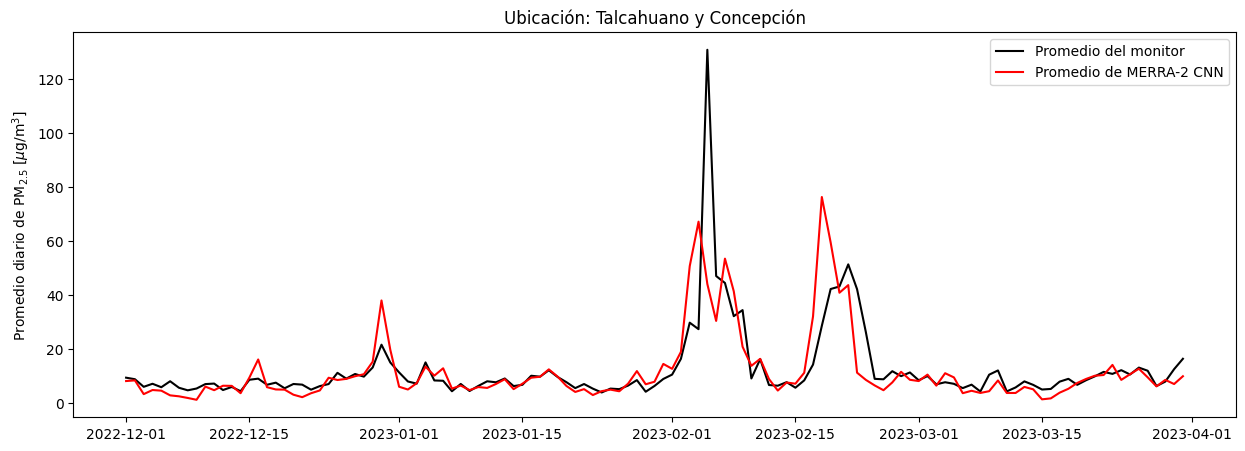

In [ ]:
# Ubicaciones:
#   Santiago:                lat -33.5, lon -70.625
#   Viña del Mar:            lat -33.0, lon -71.25
#   Talcahuano y Concepción: lat -37.0, lon -73.125

# Esta es nuestra ubicación de interés
s_location = 'Talcahuano y Concepción'

# Esta es una lista de ubicaciones de interés y sus coordenadas de celda correspondientes del conjunto de datos de MERRA-2 CNN:
d_location = {'Santiago':(-33.5,-70.625),
              'Viña del Mar':(-33.0,-71.25),
              'Talcahuano y Concepción':(-37.0,-73.125),
              }

# Seleccionar solo los datos de la celda correspondiente a la ubicación de interés:
f_data_combined_gridded_daily_at_Location = f_data_combined_gridded_daily.loc[d_location[s_location]]

# Graficar la serie de tiempo:
o_fig = plt.figure(figsize=(15,5))
o_ax = o_fig.add_subplot()
o_ax.plot(f_data_combined_gridded_daily_at_Location.index,f_data_combined_gridded_daily_at_Location['Average'],color='black',label='Promedio del monitor')
o_ax.plot(f_data_combined_gridded_daily_at_Location.index,f_data_combined_gridded_daily_at_Location['MERRA2_CNN'],color='red',label='Promedio de MERRA-2 CNN')
o_ax.legend();
o_ax.set_ylabel('Promedio diario de PM$_{2.5}$ [$\\mu$g/m$^{3}$]');
o_ax.set_title(f'Ubicación: {s_location}');
